# Carga de datos

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# Ruta base del proyecto
PROJECT = Path.home() / "Documents" / "rinde-soja"

# Cargar los 3 datasets
df_rinde = pd.read_csv(PROJECT / "data" / "raw" / "magyp" / "soja-serie-1941-2024.csv")
df_clima = pd.read_csv(PROJECT / "data" / "raw" / "nasa_power" / "nasa_power_zona_coop_1999_2025.csv", parse_dates=["fecha"])
df_ndvi = pd.read_csv(PROJECT / "data" / "raw" / "ndvi" / "ndvi_modis_zona_coop_2000_2025.csv", parse_dates=["fecha"])

print(f"Rinde: {df_rinde.shape}")
print(f"Clima: {df_clima.shape}")
print(f"NDVI:  {df_ndvi.shape}")

Rinde: (12602, 11)
Clima: (46870, 11)
NDVI:  (5800, 5)


# Armado de target (rinde por partido × campaña)

In [2]:
PARTIDOS = ["General Arenales", "Leandro N. Alem", "Junín", "Lincoln", "General Pinto"]

target = df_rinde[
    (df_rinde["provincia"] == "Buenos Aires") &
    (df_rinde["departamento"].isin(PARTIDOS)) &
    (df_rinde["anio"] >= 2000)
].copy()

target["rinde_qq_ha"] = target["rendimiento_kgxha"] / 100
target = target[["anio", "departamento", "rinde_qq_ha", "superficie_sembrada_ha", "superficie_cosechada_ha"]].copy()
target.rename(columns={"anio": "campana", "departamento": "partido"}, inplace=True)

print(f"Target: {len(target)} filas")
print(f"Campañas: {target['campana'].min()} - {target['campana'].max()}")
print(f"Partidos: {target['partido'].unique().tolist()}")
target.head()

Target: 125 filas
Campañas: 2000 - 2024
Partidos: ['General Arenales', 'General Pinto', 'Junín', 'Leandro N. Alem', 'Lincoln']


,campana,partido,rinde_qq_ha,superficie_sembrada_ha,superficie_cosechada_ha
6139,2000,General Arenales,26.48,69800,59300
6144,2000,General Pinto,24.89,39000,35550
6151,2000,Junín,25.09,80000,76600
6154,2000,Leandro N. Alem,24.27,32000,29500
6155,2000,Lincoln,23.87,64000,60000


# Definición de ventanas temporales y función auxiliar

In [4]:
# Campaña X = siembra Oct del año X, cosecha Mar-May del año X+1
# Ventanas acumulativas: cuánta info tenemos a cada corte

VENTANAS = {
    "oct_nov": (10, 11),   # Solo siembra
    "oct_dic": (10, 12),   # Temprana
    "oct_ene": (10, 13),   # 13 = enero año siguiente
    "oct_feb": (10, 14),   # 14 = febrero año siguiente (período crítico completo)
    "oct_mar": (10, 15),   # 15 = marzo año siguiente
}

def mes_campana(fecha, campana):
    """Convierte fecha real a mes relativo de la campaña.
    Oct del año de siembra = 10, Nov = 11, Dic = 12,
    Ene del año siguiente = 13, Feb = 14, Mar = 15, etc."""
    if fecha.year == campana:
        return fecha.month
    elif fecha.year == campana + 1:
        return fecha.month + 12
    return None

print("Ventanas definidas:", list(VENTANAS.keys()))

Ventanas definidas: ['oct_nov', 'oct_dic', 'oct_ene', 'oct_feb', 'oct_mar']


# Calculo de features climáticas:

In [5]:
print("Calculando features climáticas...")
clima_features = []

for campana in range(2000, 2025):
    inicio = pd.Timestamp(f"{campana}-09-01")
    fin = pd.Timestamp(f"{campana+1}-05-31")
    
    dc = df_clima[(df_clima["fecha"] >= inicio) & (df_clima["fecha"] <= fin)].copy()
    dc["mes_camp"] = dc["fecha"].apply(lambda f: mes_campana(f, campana))
    
    for partido in PARTIDOS:
        dp = dc[dc["partido"] == partido]
        if len(dp) == 0:
            continue
        
        row = {"campana": campana, "partido": partido}
        
        for ventana_nombre, (mes_ini, mes_fin) in VENTANAS.items():
            dv = dp[(dp["mes_camp"] >= mes_ini) & (dp["mes_camp"] <= mes_fin)]
            if len(dv) == 0:
                continue
            
            row[f"precip_acum_{ventana_nombre}"] = dv["PRECTOTCORR"].sum()
            row[f"temp_media_{ventana_nombre}"] = dv["T2M"].mean()
            row[f"temp_max_media_{ventana_nombre}"] = dv["T2M_MAX"].mean()
            row[f"temp_min_media_{ventana_nombre}"] = dv["T2M_MIN"].mean()
            row[f"rad_media_{ventana_nombre}"] = dv["ALLSKY_SFC_SW_DWN"].mean()
            row[f"humedad_media_{ventana_nombre}"] = dv["RH2M"].mean()
            row[f"dias_calor_extremo_{ventana_nombre}"] = (dv["T2M_MAX"] > 35).sum()
            row[f"dias_sin_lluvia_{ventana_nombre}"] = (dv["PRECTOTCORR"] < 1).sum()
        
        clima_features.append(row)

df_feat_clima = pd.DataFrame(clima_features)
print(f"Shape: {df_feat_clima.shape}")
df_feat_clima.head()

Calculando features climáticas...
Shape: (125, 42)


,campana,partido,precip_acum_oct_nov,temp_media_oct_nov,temp_max_media_oct_nov,temp_min_media_oct_nov,rad_media_oct_nov,humedad_media_oct_nov,dias_calor_extremo_oct_nov,dias_sin_lluvia_oct_nov,...,dias_calor_extremo_oct_feb,dias_sin_lluvia_oct_feb,precip_acum_oct_mar,temp_media_oct_mar,temp_max_media_oct_mar,temp_min_media_oct_mar,rad_media_oct_mar,humedad_media_oct_mar,dias_calor_extremo_oct_mar,dias_sin_lluvia_oct_mar
0,2000,General Arenales,372.54,16.807213,22.900164,10.647541,21.678033,73.807705,0,32,...,3,100,1169.71,20.357692,26.242363,14.276923,22.720495,72.856044,3,114
1,2000,Leandro N. Alem,372.54,16.807213,22.900164,10.647541,21.678033,73.807705,0,32,...,3,100,1169.71,20.357692,26.242363,14.276923,22.720495,72.856044,3,114
2,2000,Junín,372.54,16.807213,22.900164,10.647541,21.499508,73.807705,0,32,...,3,100,1169.71,20.357692,26.242363,14.276923,22.591648,72.856044,3,114
3,2000,Lincoln,353.50,16.325082,22.621475,9.950820,21.678033,73.691311,0,33,...,3,99,1071.26,20.026703,26.225879,13.633681,22.720495,72.221813,3,112
4,2000,General Pinto,326.17,16.414426,22.799508,9.981967,21.678033,72.346066,0,29,...,12,90,927.58,20.513626,27.144560,13.851209,22.720495,68.636923,12,102


# Calculo de features de NDVI:

In [6]:
print("Calculando features de NDVI...")
ndvi_features = []

for campana in range(2000, 2025):
    inicio = pd.Timestamp(f"{campana}-09-01")
    fin = pd.Timestamp(f"{campana+1}-05-31")
    
    dn = df_ndvi[(df_ndvi["fecha"] >= inicio) & (df_ndvi["fecha"] <= fin)].copy()
    dn["mes_camp"] = dn["fecha"].apply(lambda f: mes_campana(f, campana))
    
    for partido in PARTIDOS:
        dp = dn[dn["partido"] == partido]
        if len(dp) == 0:
            continue
        
        row = {"campana": campana, "partido": partido}
        
        for ventana_nombre, (mes_ini, mes_fin) in VENTANAS.items():
            dv = dp[(dp["mes_camp"] >= mes_ini) & (dp["mes_camp"] <= mes_fin)]
            if len(dv) == 0:
                continue
            
            row[f"ndvi_mean_{ventana_nombre}"] = dv["ndvi"].mean()
            row[f"ndvi_max_{ventana_nombre}"] = dv["ndvi"].max()
            row[f"ndvi_min_{ventana_nombre}"] = dv["ndvi"].min()
            row[f"ndvi_std_{ventana_nombre}"] = dv["ndvi"].std()
            
            if len(dv) >= 2:
                x = np.arange(len(dv))
                slope = np.polyfit(x, dv["ndvi"].values, 1)[0]
                row[f"ndvi_slope_{ventana_nombre}"] = slope
        
        ndvi_features.append(row)

df_feat_ndvi = pd.DataFrame(ndvi_features)
print(f"Shape: {df_feat_ndvi.shape}")
df_feat_ndvi.head()

Calculando features de NDVI...
Shape: (125, 27)


,campana,partido,ndvi_mean_oct_nov,ndvi_max_oct_nov,ndvi_min_oct_nov,ndvi_std_oct_nov,ndvi_slope_oct_nov,ndvi_mean_oct_dic,ndvi_max_oct_dic,ndvi_min_oct_dic,...,ndvi_mean_oct_feb,ndvi_max_oct_feb,ndvi_min_oct_feb,ndvi_std_oct_feb,ndvi_slope_oct_feb,ndvi_mean_oct_mar,ndvi_max_oct_mar,ndvi_min_oct_mar,ndvi_std_oct_mar,ndvi_slope_oct_mar
0,2000,General Arenales,0.550192,0.574417,0.534632,0.021261,-0.016444,0.538552,0.574417,0.504277,...,0.587671,0.741736,0.504277,0.082231,0.022401,0.605801,0.741736,0.504277,0.087003,0.019908
1,2000,Leandro N. Alem,0.609413,0.619119,0.604142,0.008416,-0.007489,0.590247,0.619119,0.557669,...,0.624987,0.721180,0.557669,0.059309,0.014174,0.636990,0.723310,0.557669,0.061122,0.012839
2,2000,Junín,0.488521,0.738377,0.051220,0.164787,0.012986,0.523574,0.801368,0.051220,...,0.561341,0.801368,0.051220,0.134292,0.003123,0.573679,0.801368,0.051220,0.129221,0.002630
3,2000,Lincoln,0.646955,0.659945,0.632611,0.013717,-0.007848,0.613995,0.659945,0.534748,...,0.623755,0.699707,0.534748,0.057450,0.002641,0.638934,0.728942,0.534748,0.062250,0.008074
4,2000,General Pinto,0.594739,0.605086,0.579000,0.013853,-0.010565,0.572421,0.605086,0.532504,...,0.602075,0.691351,0.532504,0.056298,0.011659,0.613931,0.691351,0.532504,0.057722,0.011491


# Unión de todo lo anterior

In [7]:
df_model = target.merge(df_feat_clima, on=["campana", "partido"], how="inner")
df_model = df_model.merge(df_feat_ndvi, on=["campana", "partido"], how="inner")

print(f"Shape final: {df_model.shape}")
print(f"Campañas: {df_model['campana'].min()} - {df_model['campana'].max()}")
print(f"Partidos: {df_model['partido'].unique().tolist()}")
print(f"Features: {df_model.shape[1] - 5} (sin contar target y metadatos)")
print(f"Nulls totales: {df_model.isnull().sum().sum()}")

# Guardar
output = PROJECT / "data" / "processed" / "dataset_modelado_soja.csv"
output.parent.mkdir(parents=True, exist_ok=True)
df_model.to_csv(output, index=False)
print(f"\nGuardado en: {output}")

Shape final: (125, 70)
Campañas: 2000 - 2024
Partidos: ['General Arenales', 'General Pinto', 'Junín', 'Leandro N. Alem', 'Lincoln']
Features: 65 (sin contar target y metadatos)
Nulls totales: 0

Guardado en: C:\Users\agust\Documents\rinde-soja\data\processed\dataset_modelado_soja.csv


# Gráficos de validación:

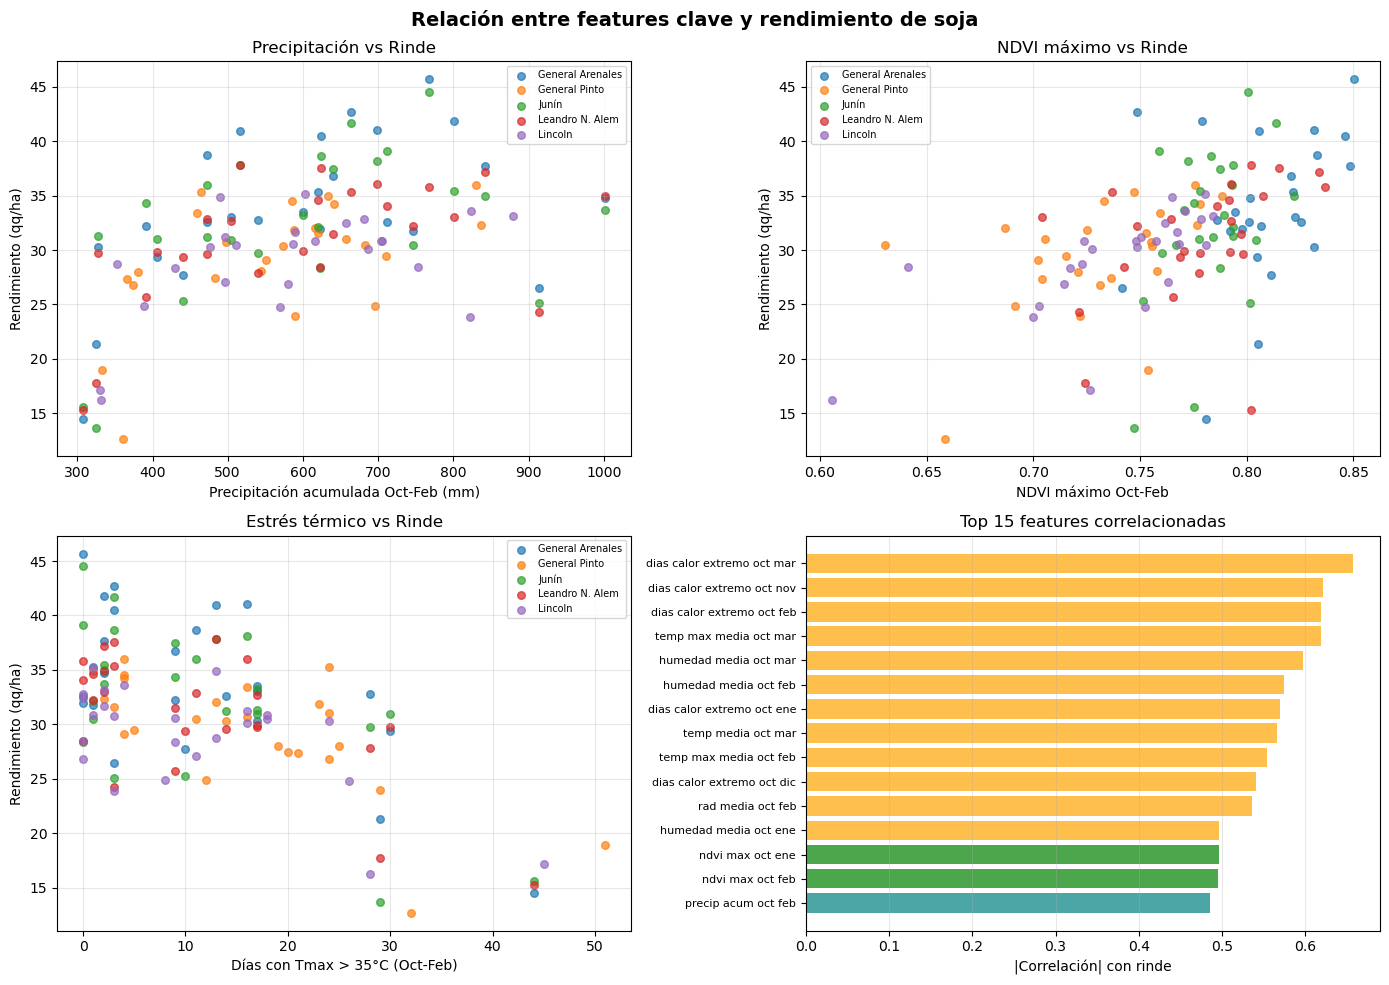

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Relación entre features clave y rendimiento de soja", fontsize=14, fontweight="bold")

for partido in df_model["partido"].unique():
    dp = df_model[df_model["partido"] == partido]
    axes[0,0].scatter(dp["precip_acum_oct_feb"], dp["rinde_qq_ha"], s=30, alpha=0.7, label=partido)
    axes[0,1].scatter(dp["ndvi_max_oct_feb"], dp["rinde_qq_ha"], s=30, alpha=0.7, label=partido)
    axes[1,0].scatter(dp["dias_calor_extremo_oct_feb"], dp["rinde_qq_ha"], s=30, alpha=0.7, label=partido)

axes[0,0].set(xlabel="Precipitación acumulada Oct-Feb (mm)", ylabel="Rendimiento (qq/ha)", title="Precipitación vs Rinde")
axes[0,1].set(xlabel="NDVI máximo Oct-Feb", ylabel="Rendimiento (qq/ha)", title="NDVI máximo vs Rinde")
axes[1,0].set(xlabel="Días con Tmax > 35°C (Oct-Feb)", ylabel="Rendimiento (qq/ha)", title="Estrés térmico vs Rinde")

for ax in [axes[0,0], axes[0,1], axes[1,0]]:
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

# Top 15 correlaciones
feature_cols = [c for c in df_model.columns if c not in ["campana","partido","rinde_qq_ha","superficie_sembrada_ha","superficie_cosechada_ha"]]
corrs = df_model[feature_cols + ["rinde_qq_ha"]].corr()["rinde_qq_ha"].drop("rinde_qq_ha").abs().sort_values(ascending=True)
top15 = corrs.tail(15)
colors = ["green" if "ndvi" in idx else "teal" if "precip" in idx else "orange" for idx in top15.index]
axes[1,1].barh(range(len(top15)), top15.values, color=colors, alpha=0.7)
axes[1,1].set_yticks(range(len(top15)))
axes[1,1].set_yticklabels([n.replace("_"," ") for n in top15.index], fontsize=8)
axes[1,1].set(xlabel="|Correlación| con rinde", title="Top 15 features correlacionadas")
axes[1,1].grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.show()